# Washington COVID-19 Data Extraction

In this notebook I prepare the Washington State COVID-19 dataset used in the later modeling and forecasting experiments.

The original Johns Hopkins file contains data for the whole United States at county level. My goal here is to isolate Washington, combine all Washington counties into one state-level cumulative time series, keep the study period starting from March 2020, verify the result visually, and save a clean CSV for the next notebooks.

**Main output:** `washington_covid_confirmed.csv`


## 1. Import libraries and load the original Johns Hopkins dataset

I first import all libraries needed in this notebook and load the U.S. confirmed-cases time-series file directly from the Johns Hopkins GitHub repository.

At this stage the data are still at the **county level**, so Washington appears in multiple rows rather than as one state-level row. I also print the shape and preview the file to understand its structure before filtering.


In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_US.csv"

df = pd.read_csv(url)

print(df.shape)
df.head()


(3342, 1154)


,UID,iso2,iso3,code3,FIPS,Admin2,Province_State,Country_Region,Lat,Long_,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,84001001,US,USA,840,1001.0,Autauga,Alabama,US,32.539527,-86.644082,...,19732,19759,19759,19759,19759,19759,19759,19759,19790,19790
1,84001003,US,USA,840,1003.0,Baldwin,Alabama,US,30.727750,-87.722071,...,69641,69767,69767,69767,69767,69767,69767,69767,69860,69860
2,84001005,US,USA,840,1005.0,Barbour,Alabama,US,31.868263,-85.387129,...,7451,7474,7474,7474,7474,7474,7474,7474,7485,7485
3,84001007,US,USA,840,1007.0,Bibb,Alabama,US,32.996421,-87.125115,...,8067,8087,8087,8087,8087,8087,8087,8087,8091,8091
4,84001009,US,USA,840,1009.0,Blount,Alabama,US,33.982109,-86.567906,...,18616,18673,18673,18673,18673,18673,18673,18673,18704,18704


## 2. Check the available state names

Before filtering, I inspect the unique values in `Province_State`.

This is a simple verification step to make sure that **Washington** exists exactly under that name and to avoid accidentally confusing Washington State with the District of Columbia.


In [2]:
df["Province_State"].unique()


<ArrowStringArray>
[                 'Alabama',                   'Alaska',
           'American Samoa',                  'Arizona',
                 'Arkansas',               'California',
                 'Colorado',              'Connecticut',
                 'Delaware',         'Diamond Princess',
     'District of Columbia',                  'Florida',
                  'Georgia',           'Grand Princess',
                     'Guam',                   'Hawaii',
                    'Idaho',                 'Illinois',
                  'Indiana',                     'Iowa',
                   'Kansas',                 'Kentucky',
                'Louisiana',                    'Maine',
                 'Maryland',            'Massachusetts',
                 'Michigan',                'Minnesota',
              'Mississippi',                 'Missouri',
                  'Montana',                 'Nebraska',
                   'Nevada',            'New Hampshire',
            

## 3. Filter only Washington rows

Here I keep only records where `Province_State == "Washington"`.

The important point is that the result still contains **multiple rows**, because each row represents a county or reporting area in Washington. I display `Admin2` and `Province_State` so I can confirm that the filtering worked correctly.


In [3]:
washington = df[df["Province_State"] == "Washington"].copy()

print(washington.shape)

washington[
    ["Admin2", "Province_State"]
].head(20)


(41, 1154)


,Admin2,Province_State
3145,Adams,Washington
3146,Asotin,Washington
3147,Benton,Washington
3148,Chelan,Washington
3149,Clallam,Washington
3150,Clark,Washington
3151,Columbia,Washington
3152,Cowlitz,Washington
3153,Douglas,Washington
3154,Ferry,Washington


## 4. Identify the date columns

The Johns Hopkins file contains metadata columns first, followed by hundreds of date columns such as `1/22/20`, `1/23/20`, etc.

I use a regular expression to select only columns that match the date format. These are the columns that contain the cumulative confirmed-case counts and will be aggregated in the next step.


In [4]:
date_cols = [
    col for col in df.columns
    if re.match(r"^\d{1,2}/\d{1,2}/\d{2}$", str(col))
]

print("Number of dates:", len(date_cols))
print("First date:", date_cols[0])
print("Last date:", date_cols[-1])


Number of dates: 1143
First date: 1/22/20
Last date: 3/9/23


## 5. Aggregate counties into a Washington State total

Because the source data are county-level, I sum every Washington county **column-wise for each date**.

After this operation, I have one value per date representing the cumulative number of confirmed cases for the whole state of Washington. This is the main aggregation step that converts the original county dataset into the state-level series needed for the paper reproduction.


In [5]:
washington_total = washington[date_cols].sum(axis=0)

washington_total.head()


1/22/20    1
1/23/20    1
1/24/20    1
1/25/20    1
1/26/20    1
dtype: int64

## 6. Convert the aggregated series into a clean dataframe

The state totals are currently stored as a pandas Series whose index contains the dates.

I reset the index, rename the two columns to `Date` and `ConfirmedCases`, and convert the date strings into proper datetime values. The result is now a simple time-series table with one row per day.


In [6]:
washington_df = washington_total.reset_index()

washington_df.columns = ["Date", "ConfirmedCases"]

washington_df["Date"] = pd.to_datetime(
    washington_df["Date"],
    format="%m/%d/%y"
)

washington_df.head(50)


,Date,ConfirmedCases
0,2020-01-22,1
1,2020-01-23,1
2,2020-01-24,1
3,2020-01-25,1
4,2020-01-26,1
5,2020-01-27,1
6,2020-01-28,1
7,2020-01-29,1
8,2020-01-30,1
9,2020-01-31,1


## 7. Keep the study period starting from March 2020

The paper analyzes the pandemic beginning around March 2020, so I remove the earlier January and February observations.

This keeps the dataset aligned with the period used in the study as closely as the publicly available Johns Hopkins data allow.


In [7]:
washington_df = washington_df[
    washington_df["Date"] >= "2020-03-01"
].reset_index(drop=True)

washington_df.head()


,Date,ConfirmedCases
0,2020-03-01,11
1,2020-03-02,18
2,2020-03-03,27
3,2020-03-04,39
4,2020-03-05,70


## 8. Verify the final extracted dataset

Before saving anything, I check the number of rows and the first and last dates.

This is an important sanity check because all later SMA, EWMA, Holt-Winters, and LSTM experiments depend on this exact time series.


In [8]:
print("Rows:", len(washington_df))
print("Start:", washington_df["Date"].min())
print("End:", washington_df["Date"].max())

washington_df.head(10)


Rows: 1104
Start: 2020-03-01 00:00:00
End: 2023-03-09 00:00:00


,Date,ConfirmedCases
0,2020-03-01,11
1,2020-03-02,18
2,2020-03-03,27
3,2020-03-04,39
4,2020-03-05,70
5,2020-03-06,78
6,2020-03-07,102
7,2020-03-08,122
8,2020-03-09,122
9,2020-03-10,167


## 9. Plot the raw Washington cumulative case series

This plot is only a **visual verification of the extracted data**; no modeling is performed here.

I expect cumulative confirmed cases to generally increase over time. The graph also helps me see major changes in the growth rate and confirm that the aggregation did not produce an obviously incorrect series.


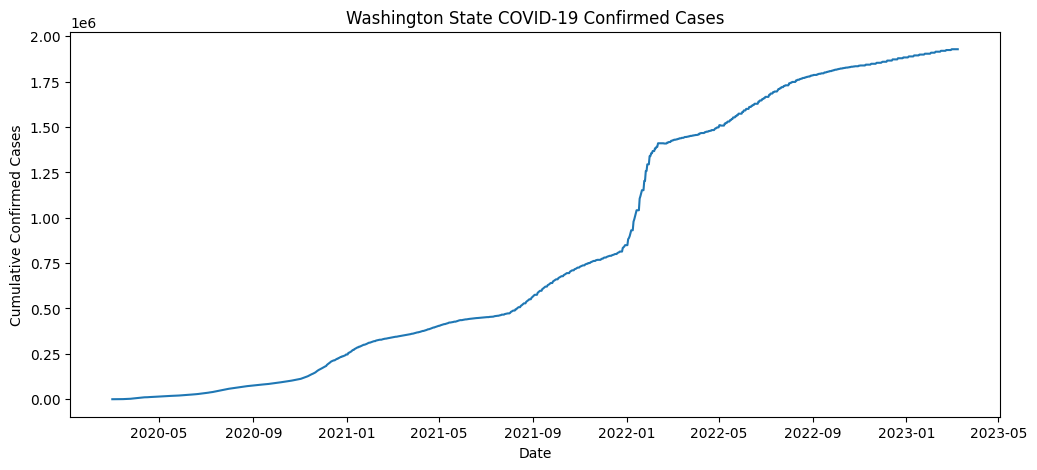

In [9]:
plt.figure(figsize=(12, 5))

plt.plot(
    washington_df["Date"],
    washington_df["ConfirmedCases"]
)

plt.xlabel("Date")
plt.ylabel("Cumulative Confirmed Cases")
plt.title("Washington State COVID-19 Confirmed Cases")

plt.show()


## 10. Save the cleaned Washington dataset

Finally, I save the state-level time series as `washington_covid_confirmed.csv`.

This separates data preparation from modeling. The next notebooks can load this small clean file directly instead of repeating the full Johns Hopkins extraction process.


In [10]:
washington_df.to_csv(
    "washington_covid_confirmed.csv",
    index=False
)
